# Probe Vector Explorer- **Qwen2.5-3B** (base) | **Qwen2.5-3B-Instruct** (aligned) | **AZR-Coder-3B** (self-evolved)

In [1]:
import sys
!{sys.executable} -m pip install matplotlib ipympl numpy scikit-learn ipywidgets


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: D:\python\python3.12.7\python.exe -m pip install --upgrade pip


In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider, Dropdown, Layout, IntRangeSlider
import warnings
warnings.filterwarnings('ignore')

In [3]:
NPZ_PATHS = {
    'Qwen2.5-3B': '../results/Qwen2.5-3B/20260422-1053/probe_vectors/Qwen2.5-3B/20260422-1121.npz',
    'Qwen2.5-3B-Instruct': '../results/Qwen2.5-3B-Instruct/20260422-1053/probe_vectors/Qwen2.5-3B-Instruct/20260422-1122.npz',
    'AZR-Coder-3B': '../results/AZR-Coder-3B/20260422-1053/probe_vectors/Absolute_Zero_Reasoner-Coder-3b/20260422-1123.npz',
}
models = {}
for name, path in NPZ_PATHS.items():
    d = dict(np.load(path, allow_pickle=True))
    d['tags_order'] = list(d['tags_order'])
    models[name] = d
    print(f'Loaded {name}: {d["probe_coefs"].shape}')

MN = list(models.keys())
NL = 36
TAGS = models[MN[0]]['tags_order']
TC = {'harmful':'#E53935','safe':'#43A047','factual':'#7CB342','reasoning':'#5C6BC0'}
MC = {'Qwen2.5-3B':'#2196F3','Qwen2.5-3B-Instruct':'#FF9800','AZR-Coder-3B':'#4CAF50'}

Loaded Qwen2.5-3B: (36, 4, 2048)
Loaded Qwen2.5-3B-Instruct: (36, 4, 2048)
Loaded AZR-Coder-3B: (36, 4, 2048)


In [4]:
all_v = []
for n in MN:
    c = models[n]['probe_coefs']
    for l in range(NL):
        for k in range(len(TAGS)):
            all_v.append(c[l,k])
pca = PCA(n_components=3).fit(np.stack(all_v))
print(f'PCA: {pca.explained_variance_ratio_[0]:.1%}, {pca.explained_variance_ratio_[1]:.1%}, {pca.explained_variance_ratio_[2]:.1%}')

pcp = {}
for n in MN:
    pcp[n] = {}
    for k,tag in enumerate(TAGS):
        pcp[n][tag] = pca.transform(models[n]['probe_coefs'][:,k,:])

PCA: 14.6%, 11.0%, 10.7%


## 1. Layer-by-Layer Behavior Direction Explorer (3D)Drag **Layer** slider + drag to rotate the 3D view.

interactive(children=(IntSlider(value=0, description='Layer:', layout=Layout(width='600px'), max=35, style=Sli…

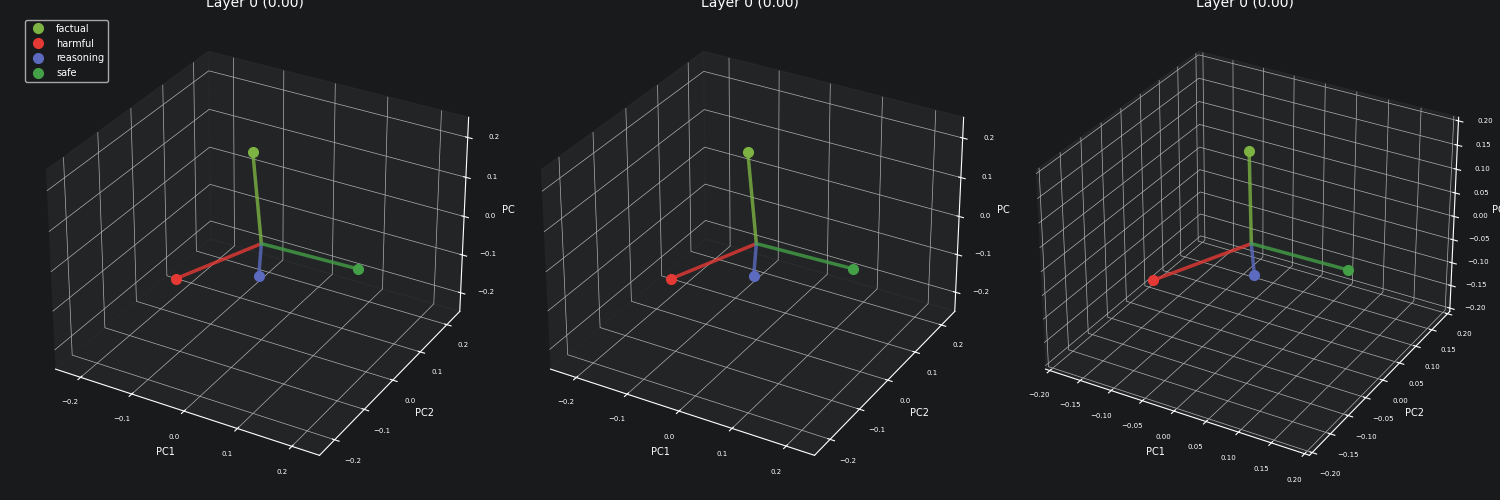

In [5]:
fig1 = plt.figure(figsize=(15,5))
fig1.canvas.header_visible = False
ax1 = [fig1.add_subplot(1,3,i+1,projection='3d') for i in range(3)]
_a1={}; _d1={}; _t1={}
for i,mn in enumerate(MN):
    ax=ax1[i]; ax.set_xlabel('PC1',fontsize=7,labelpad=0); ax.set_ylabel('PC2',fontsize=7,labelpad=0); ax.set_zlabel('PC3',fontsize=7,labelpad=0)
    ax.tick_params(labelsize=5); _t1[mn]=ax.set_title(mn,fontsize=10)
    _a1[mn]=[]; _d1[mn]=[]
    for c,tag in enumerate(TAGS):
        ln,=ax.plot([0,0],[0,0],[0,0],'-',color=TC[tag],lw=2.5,alpha=0.8)
        dt,=ax.plot([0],[0],[0],'o',color=TC[tag],ms=7,label=tag if i==0 else '',zorder=5)
        _a1[mn].append(ln); _d1[mn].append(dt)
ax1[0].legend(loc='upper left',fontsize=7)
fig1.tight_layout()

def u1(layer=0):
    for i,mn in enumerate(MN):
        ax=ax1[i]; p=pca.transform(models[mn]['probe_coefs'][layer]); mr=0
        for c,tag in enumerate(TAGS):
            x,y,z=p[c]; _a1[mn][c].set_data_3d([0,x],[0,y],[0,z]); _d1[mn][c].set_data_3d([x],[y],[z])
            mr=max(mr,abs(x),abs(y),abs(z))
        m=mr*1.3+0.01; ax.set_xlim(-m,m); ax.set_ylim(-m,m); ax.set_zlim(-m,m)
        _t1[mn].set_text(f'{mn}\nLayer {layer} ({layer/NL:.2f})')
    fig1.canvas.draw_idle()

interact(u1,layer=IntSlider(value=0,min=0,max=35,step=1,description='Layer:',
    continuous_update=True,style={'description_width':'50px'},layout=Layout(width='600px')));

## 2. Cross-Layer Direction Dynamics

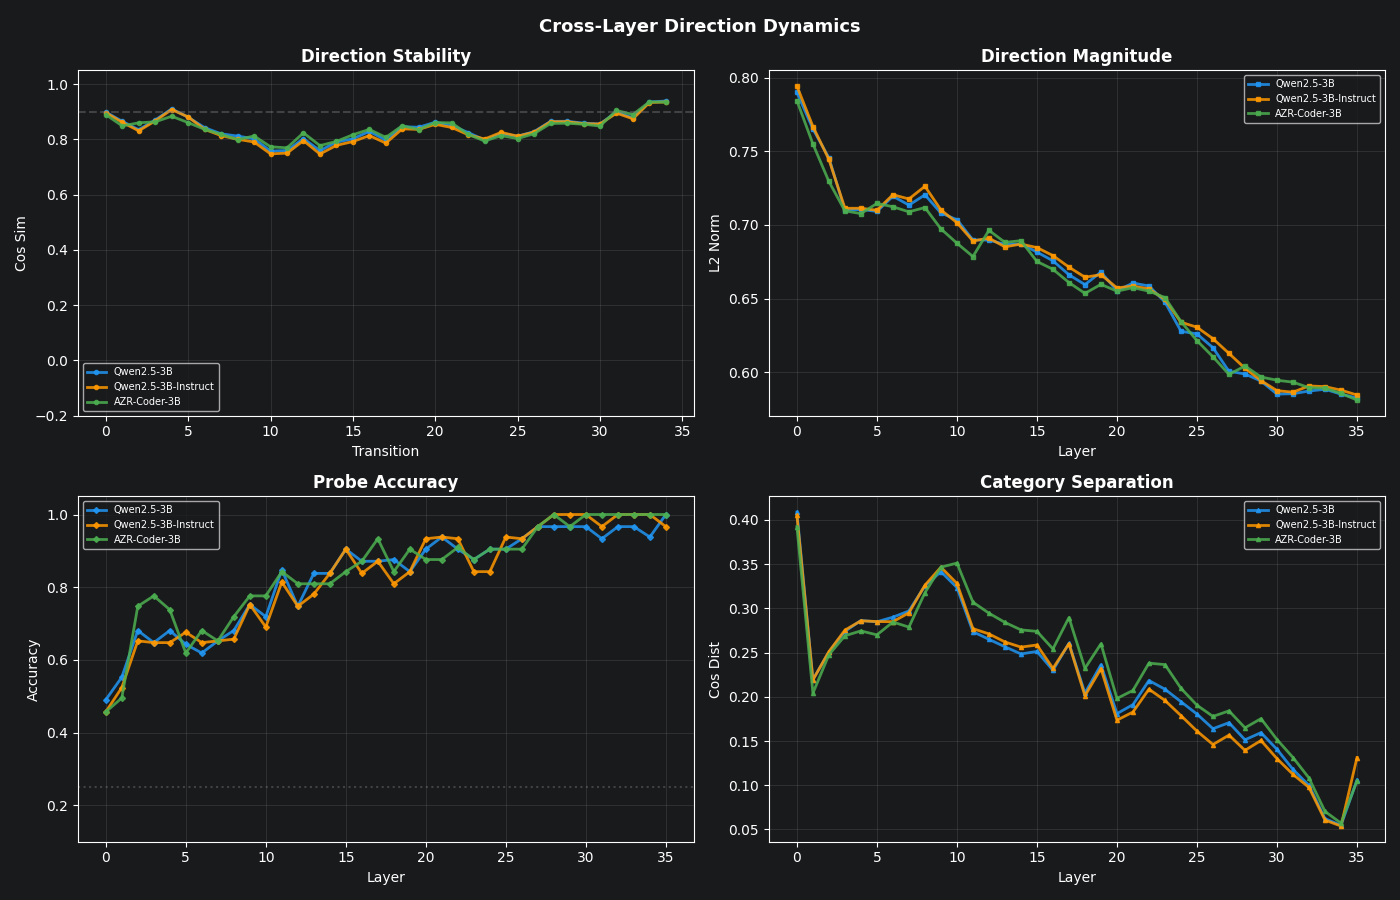

In [6]:
fig2,axs2=plt.subplots(2,2,figsize=(14,9)); fig2.canvas.header_visible=False
ps=[('direction_cosine','Cos Sim','Direction Stability','o-','Transition'),
    ('direction_norm','L2 Norm','Direction Magnitude','s-','Layer'),
    ('probe_accuracy','Accuracy','Probe Accuracy','D-','Layer'),
    ('mean_separation','Cos Dist','Category Separation','^-','Layer')]
for i,(k,yl,t,mk,xl) in enumerate(ps):
    ax=axs2[i//2,i%2]
    for n in MN:
        d=models[n][k]; ax.plot(range(len(d)),d,mk,color=MC[n],lw=2,ms=3,label=n,alpha=0.85)
    if k=='direction_cosine': ax.axhline(0.9,color='gray',ls='--',alpha=0.4); ax.set_ylim(-0.2,1.05)
    if k=='probe_accuracy': ax.axhline(0.25,color='gray',ls=':',alpha=0.4); ax.set_ylim(0.1,1.05)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(t,fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.2)
fig2.suptitle('Cross-Layer Direction Dynamics',fontsize=13,fontweight='bold')
fig2.tight_layout()

## 3. Behavioral Information Concentration (BIC)

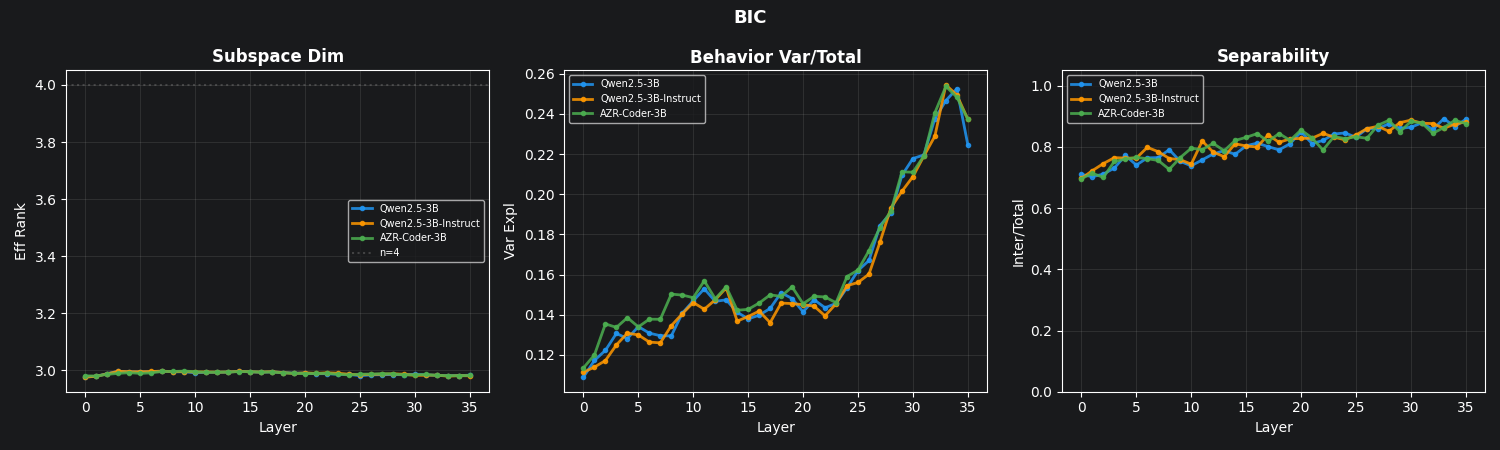

In [7]:
fig3,axs3=plt.subplots(1,3,figsize=(15,4.5)); fig3.canvas.header_visible=False
bs=[('bic_effective_rank','Eff Rank','Subspace Dim'),('bic_explained_ratio','Var Expl','Behavior Var/Total'),('bic_inter_class_ratio','Inter/Total','Separability')]
for i,(k,yl,t) in enumerate(bs):
    ax=axs3[i]
    for n in MN: ax.plot(range(len(models[n][k])),models[n][k],'o-',color=MC[n],lw=2,ms=3,label=n,alpha=0.85)
    if k=='bic_effective_rank': ax.axhline(len(TAGS),color='gray',ls=':',alpha=0.4,label=f'n={len(TAGS)}')
    if k=='bic_inter_class_ratio': ax.set_ylim(0,1.05)
    ax.set_xlabel('Layer'); ax.set_ylabel(yl); ax.set_title(t,fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.2)
fig3.suptitle('BIC',fontsize=13,fontweight='bold'); fig3.tight_layout()

## 4. Per-Class Direction Trajectory (3D)Drag slider to grow trajectory. Rotate by dragging.

interactive(children=(IntSlider(value=35, description='To Layer:', layout=Layout(width='600px'), max=35, min=1…

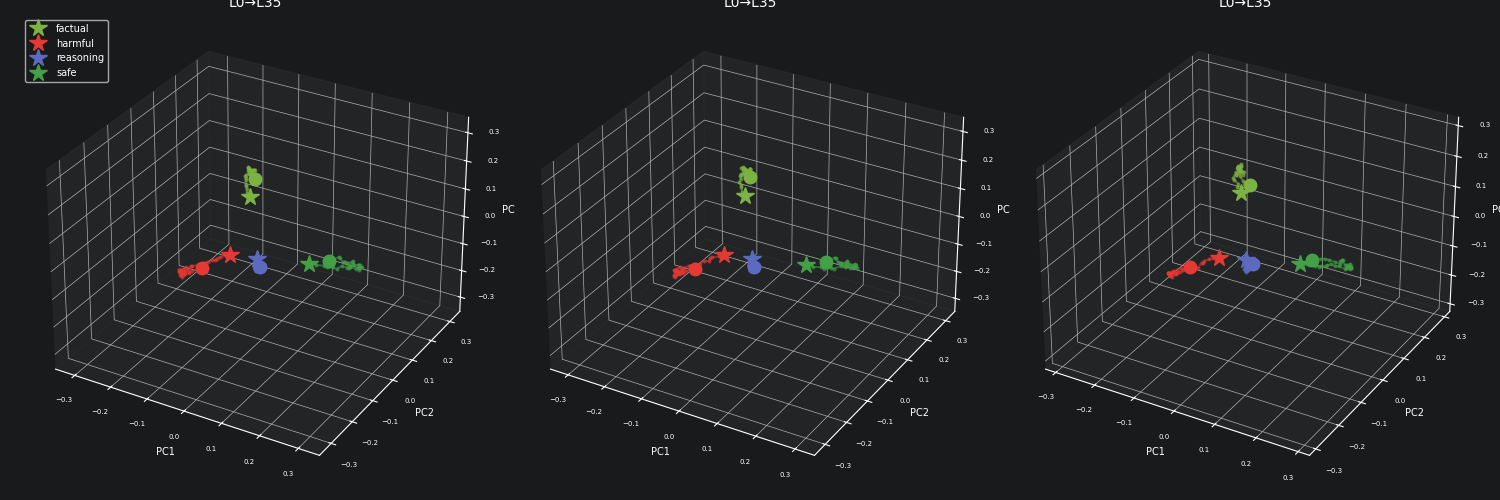

In [13]:
fig4=plt.figure(figsize=(15,5)); fig4.canvas.header_visible=False
ax4=[fig4.add_subplot(1,3,i+1,projection='3d') for i in range(3)]
_tl={}; _td={}; _ts={}; _te={}; _tt={}
for i,mn in enumerate(MN):
    ax=ax4[i]; ax.set_xlabel('PC1',fontsize=7,labelpad=0); ax.set_ylabel('PC2',fontsize=7,labelpad=0); ax.set_zlabel('PC3',fontsize=7,labelpad=0)
    ax.tick_params(labelsize=5); _tt[mn]=ax.set_title(mn,fontsize=10)
    _tl[mn]={}; _td[mn]={}; _ts[mn]={}; _te[mn]={}
    for tag in TAGS:
        c=TC[tag]
        ln,=ax.plot([],[],[],'o-',color=c,lw=1.5,ms=2,alpha=0.5)
        st,=ax.plot([],[],[],'o',color=c,ms=9,zorder=5)
        en,=ax.plot([],[],[],'*',color=c,ms=13,zorder=5,label=tag if i==0 else '')
        _tl[mn][tag]=ln; _ts[mn][tag]=st; _te[mn][tag]=en
ax4[0].legend(loc='upper left',fontsize=7); fig4.tight_layout()

def u4(layer_end=35):
    for i,mn in enumerate(MN):
        ax=ax4[i]; mr=0
        for tag in TAGS:
            p=pcp[mn][tag][:layer_end+1]
            _tl[mn][tag].set_data_3d(p[:,0],p[:,1],p[:,2])
            _ts[mn][tag].set_data_3d([p[0,0]],[p[0,1]],[p[0,2]])
            _te[mn][tag].set_data_3d([p[-1,0]],[p[-1,1]],[p[-1,2]])
            mr=max(mr,np.abs(p).max())
        m=mr*1.3+0.01; ax.set_xlim(-m,m); ax.set_ylim(-m,m); ax.set_zlim(-m,m)
        _tt[mn].set_text(f'{mn}\nL0\u2192L{layer_end}')
    fig4.canvas.draw_idle()

interact(u4,layer_end=IntSlider(value=35,min=1,max=35,step=1,description='To Layer:',
    continuous_update=True,style={'description_width':'70px'},layout=Layout(width='600px')));

## 5. Cross-Layer Similarity Heatmap

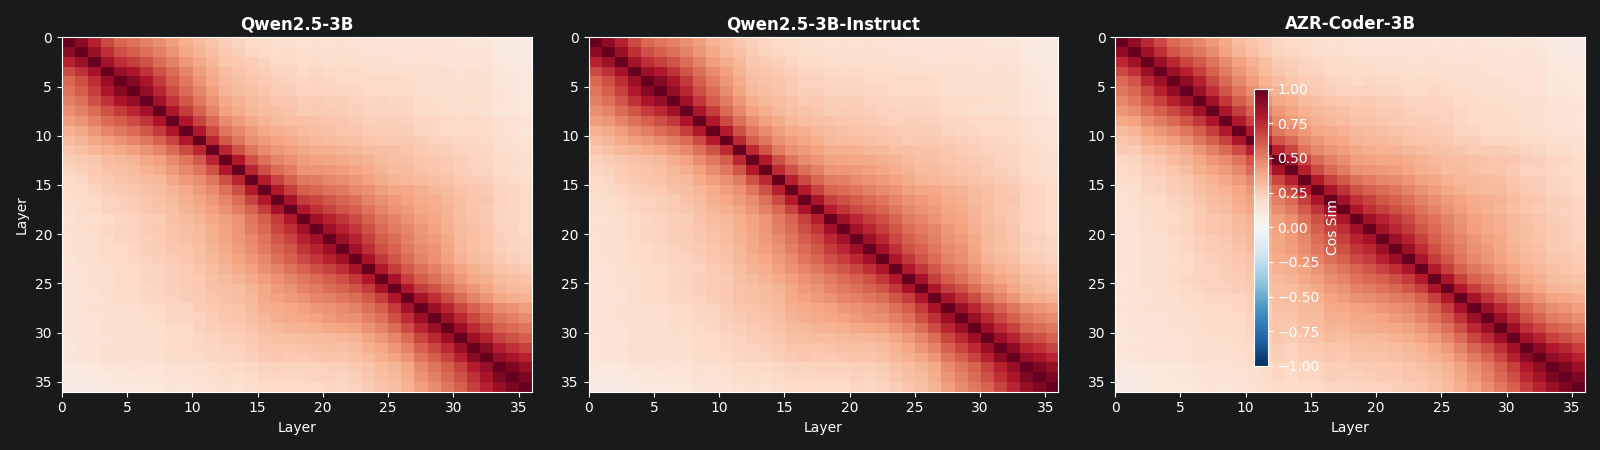

In [9]:
fig5,axes5=plt.subplots(1,3,figsize=(16,4.5)); fig5.canvas.header_visible=False
for i,mn in enumerate(MN):
    ax=axes5[i]; flat=models[mn]['probe_coefs'].reshape(NL,-1)
    nrm=np.maximum(np.linalg.norm(flat,axis=1,keepdims=True),1e-10)
    sim=(flat/nrm)@(flat/nrm).T
    im=ax.imshow(sim,cmap='RdBu_r',vmin=-1,vmax=1,aspect='auto',extent=[0,NL,NL,0])
    ax.set_xlabel('Layer'); ax.set_title(mn,fontweight='bold')
    if i==0: ax.set_ylabel('Layer')
fig5.colorbar(im,ax=axes5.tolist(),label='Cos Sim',shrink=0.8); fig5.tight_layout()

## 6. Per-Class Norm Evolution

interactive(children=(Dropdown(description='Model:', options=('Qwen2.5-3B', 'Qwen2.5-3B-Instruct', 'AZR-Coder-…

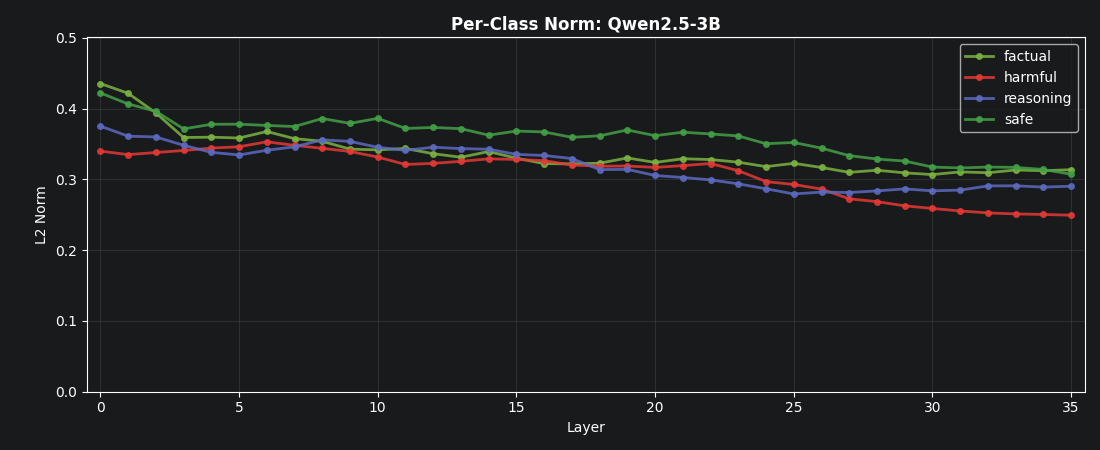

In [10]:
fig6,ax6=plt.subplots(figsize=(11,4.5)); fig6.canvas.header_visible=False
ax6.set_xlabel('Layer'); ax6.set_ylabel('L2 Norm'); ax6.grid(True,alpha=0.2)
_nl={}
for tag in TAGS:
    ln,=ax6.plot([],[],'o-',color=TC[tag],lw=2,ms=4,label=tag,alpha=0.85); _nl[tag]=ln
ax6.legend(fontsize=10); _nt=ax6.set_title('Per-Class Norm',fontweight='bold'); fig6.tight_layout()

def u6(model='Qwen2.5-3B'):
    co=models[model]['probe_coefs']; mv=0
    for c,tag in enumerate(TAGS):
        n=np.linalg.norm(co[:,c,:],axis=1); _nl[tag].set_data(range(NL),n); mv=max(mv,n.max())
    ax6.set_xlim(-0.5,NL-0.5); ax6.set_ylim(0,mv*1.15)
    _nt.set_text(f'Per-Class Norm: {model}'); fig6.canvas.draw_idle()

interact(u6,model=Dropdown(options=MN,value=MN[0],description='Model:'));

## 7. Pairwise Class Direction Similarity

interactive(children=(IntSlider(value=0, description='Layer:', layout=Layout(width='600px'), max=35, style=Sli…

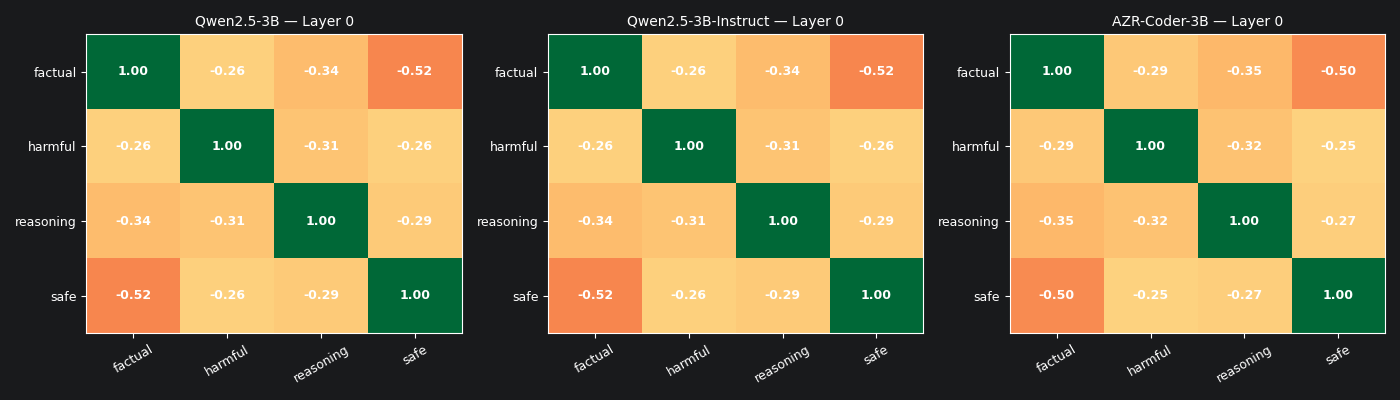

In [11]:
fig7,axes7=plt.subplots(1,3,figsize=(14,4)); fig7.canvas.header_visible=False
_hm={}; _ht={}; _htx={}
for i,mn in enumerate(MN):
    ax=axes7[i]; dm=np.zeros((len(TAGS),len(TAGS)))
    im=ax.imshow(dm,cmap='RdYlGn',vmin=-1,vmax=1,aspect='auto')
    ax.set_xticks(range(len(TAGS))); ax.set_xticklabels(TAGS,fontsize=9,rotation=30)
    ax.set_yticks(range(len(TAGS))); ax.set_yticklabels(TAGS,fontsize=9)
    _ht[mn]=ax.set_title(mn,fontsize=10); _hm[mn]=im
    tx=[]
    for r in range(len(TAGS)):
        for c in range(len(TAGS)):
            tx.append(ax.text(c,r,'',ha='center',va='center',fontsize=9,fontweight='bold'))
    _htx[mn]=tx
fig7.tight_layout()

def u7(layer=0):
    for mn in MN:
        co=models[mn]['probe_coefs'][layer]
        nrm=np.maximum(np.linalg.norm(co,axis=1,keepdims=True),1e-10)
        sim=(co/nrm)@(co/nrm).T; _hm[mn].set_data(sim)
        _ht[mn].set_text(f'{mn} \u2014 Layer {layer}')
        for r in range(len(TAGS)):
            for c in range(len(TAGS)):
                _htx[mn][r*len(TAGS)+c].set_text(f'{sim[r,c]:.2f}')
    fig7.canvas.draw_idle()

interact(u7,layer=IntSlider(value=0,min=0,max=35,step=1,description='Layer:',
    continuous_update=True,style={'description_width':'50px'},layout=Layout(width='600px')));

## 8. Layer Range Comparison (3D)

interactive(children=(IntRangeSlider(value=(0, 35), description='Layers:', layout=Layout(width='600px'), max=3…

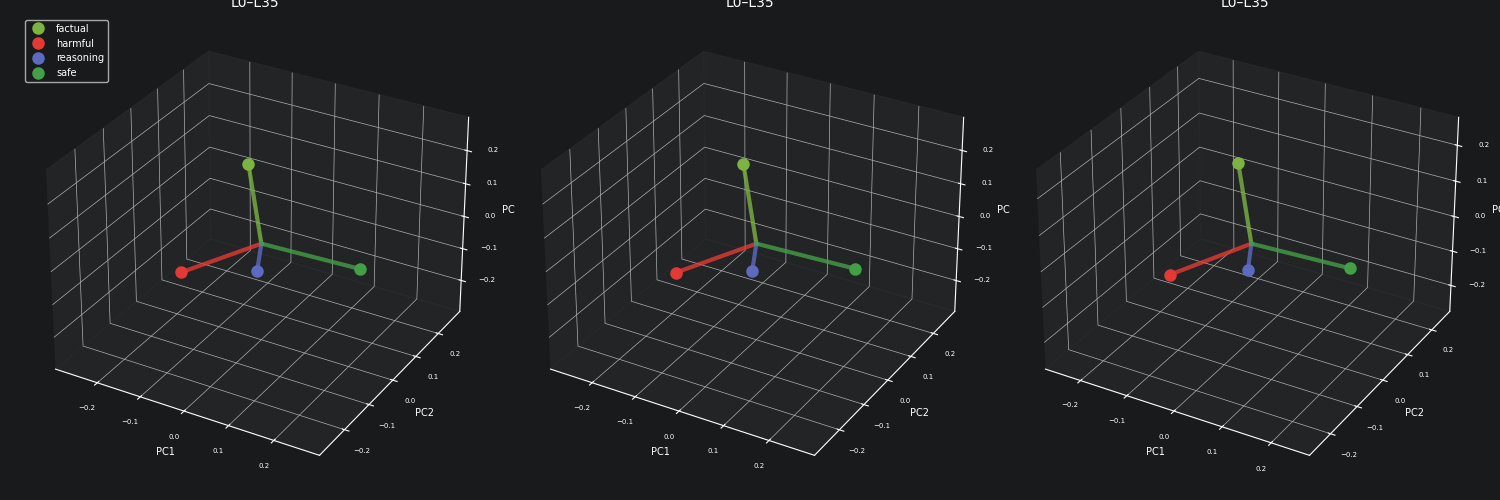

In [12]:
fig8=plt.figure(figsize=(15,5)); fig8.canvas.header_visible=False
ax8=[fig8.add_subplot(1,3,i+1,projection='3d') for i in range(3)]
_ra={}; _rd={}; _rt8={}
for i,mn in enumerate(MN):
    ax=ax8[i]; ax.set_xlabel('PC1',fontsize=7,labelpad=0); ax.set_ylabel('PC2',fontsize=7,labelpad=0); ax.set_zlabel('PC3',fontsize=7,labelpad=0)
    ax.tick_params(labelsize=5); _rt8[mn]=ax.set_title(mn,fontsize=10)
    _ra[mn]=[]; _rd[mn]=[]
    for ci,tag in enumerate(TAGS):
        ln,=ax.plot([0,0],[0,0],[0,0],'-',color=TC[tag],lw=3,alpha=0.8)
        dt,=ax.plot([0],[0],[0],'o',color=TC[tag],ms=8,label=tag if i==0 else '',zorder=5)
        _ra[mn].append(ln); _rd[mn].append(dt)
ax8[0].legend(loc='upper left',fontsize=7); fig8.tight_layout()

def u8(layer_range=(0,35)):
    s,e=layer_range
    for i,mn in enumerate(MN):
        ax=ax8[i]; mc=models[mn]['probe_coefs'][s:e+1].mean(axis=0)
        p=pca.transform(mc); mr=0
        for ci,tag in enumerate(TAGS):
            x,y,z=p[ci]; _ra[mn][ci].set_data_3d([0,x],[0,y],[0,z]); _rd[mn][ci].set_data_3d([x],[y],[z])
            mr=max(mr,abs(x),abs(y),abs(z))
        m=mr*1.3+0.01; ax.set_xlim(-m,m); ax.set_ylim(-m,m); ax.set_zlim(-m,m)
        _rt8[mn].set_text(f'{mn}\nL{s}\u2013L{e}')
    fig8.canvas.draw_idle()

interact(u8,layer_range=IntRangeSlider(value=[0,35],min=0,max=35,step=1,description='Layers:',
    continuous_update=True,style={'description_width':'60px'},layout=Layout(width='600px')));